Iteration   1 | k_eff = 0.667793 | error = 3.322e-01
Iteration   2 | k_eff = 0.723542 | error = 5.575e-02
Iteration   3 | k_eff = 0.735399 | error = 1.186e-02
Iteration   4 | k_eff = 0.741057 | error = 5.658e-03
Iteration   5 | k_eff = 0.744325 | error = 3.268e-03
Iteration   6 | k_eff = 0.746384 | error = 2.059e-03
Iteration   7 | k_eff = 0.747743 | error = 1.358e-03
Iteration   8 | k_eff = 0.748661 | error = 9.189e-04
Iteration   9 | k_eff = 0.749292 | error = 6.305e-04
Iteration  10 | k_eff = 0.749728 | error = 4.362e-04
Iteration  11 | k_eff = 0.750031 | error = 3.032e-04
Iteration  12 | k_eff = 0.750243 | error = 2.113e-04
Iteration  13 | k_eff = 0.750390 | error = 1.475e-04
Iteration  14 | k_eff = 0.750493 | error = 1.031e-04
Iteration  15 | k_eff = 0.750565 | error = 7.203e-05
Iteration  16 | k_eff = 0.750616 | error = 5.035e-05
Iteration  17 | k_eff = 0.750651 | error = 3.521e-05
Iteration  18 | k_eff = 0.750676 | error = 2.462e-05
Iteration  19 | k_eff = 0.750693 | error = 1.7

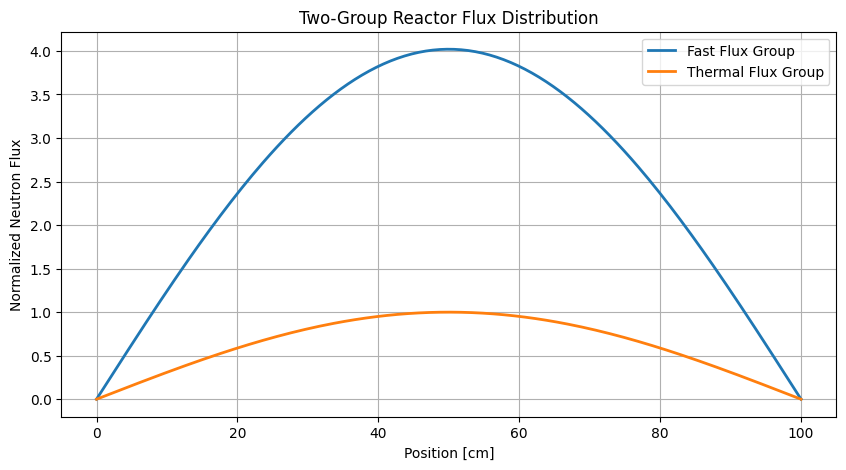

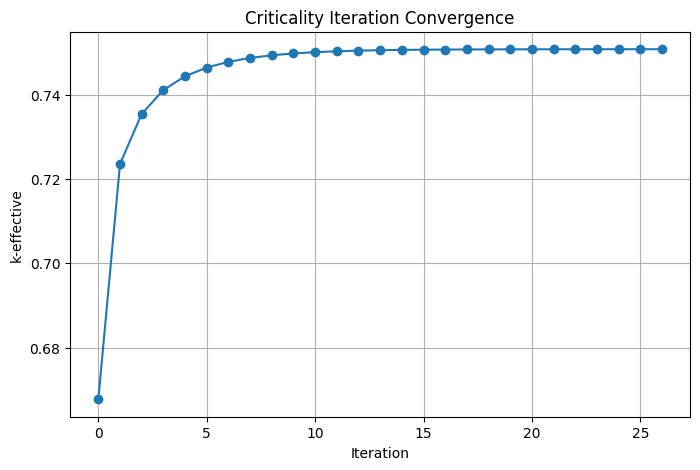


 FINAL RESULTS
k-effective = 0.750731
System is SUBCRITICAL


In [1]:
# Simplified Two-Group Neutron Criticality Simulation
# ==================================================
#
# This notebook implements a simplified 1D two-group neutron diffusion
# criticality calculation for a nuclear reactor.
#
# Physics included:
# - Fast and thermal neutron groups
# - Diffusion approximation
# - Downscattering from fast to thermal group
# - Thermal fission neutron production
# - Power iteration for k-effective
#
# The model solves:
#
# Group 1 (fast):
#   -D1 d²phi1/dx² + Sa1*phi1 + S12*phi1 = (1/k) * nuSigmaF2 * phi2
#
# Group 2 (thermal):
#   -D2 d²phi2/dx² + Sa2*phi2 = S12 * phi1
#
# Boundary conditions:
#   Vacuum (zero flux at boundaries)
#
# ==================================================

import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Geometry and mesh
# --------------------------------------------------

L = 100.0              # reactor length [cm]
N = 200                # number of spatial cells
dx = L / (N - 1)

x = np.linspace(0, L, N)

# --------------------------------------------------
# Two-group material constants
# --------------------------------------------------
#
# Group 1 = fast neutrons
# Group 2 = thermal neutrons
#

# Diffusion coefficients [cm]
D1 = 1.5
D2 = 0.4

# Absorption cross sections [1/cm]
SigmaA1 = 0.010
SigmaA2 = 0.080

# Downscatter from fast -> thermal [1/cm]
SigmaS12 = 0.020

# Thermal fission production [1/cm]
nuSigmaF2 = 0.095

# --------------------------------------------------
# Initial flux guesses
# --------------------------------------------------

phi1 = np.ones(N)
phi2 = np.ones(N)

# Normalize
phi1 /= np.max(phi1)
phi2 /= np.max(phi2)

# --------------------------------------------------
# Solver settings
# --------------------------------------------------

max_iters = 500
tolerance = 1e-6

k_eff = 1.0

# --------------------------------------------------
# Matrix assembly helper
# --------------------------------------------------

def diffusion_matrix(D, SigmaR, N, dx):

    A = np.zeros((N, N))

    coef = D / dx**2

    for i in range(1, N-1):

        A[i, i-1] = -coef
        A[i, i]   = 2*coef + SigmaR
        A[i, i+1] = -coef

    # Vacuum boundaries
    A[0,0] = 1.0
    A[-1,-1] = 1.0

    return A

# --------------------------------------------------
# Construct matrices
# --------------------------------------------------

A1 = diffusion_matrix(
    D1,
    SigmaA1 + SigmaS12,
    N,
    dx
)

A2 = diffusion_matrix(
    D2,
    SigmaA2,
    N,
    dx
)

# --------------------------------------------------
# Power iteration for k-effective
# --------------------------------------------------

k_history = []

for iteration in range(max_iters):

    # ----------------------------------------------
    # Old fluxes
    # ----------------------------------------------

    phi1_old = phi1.copy()
    phi2_old = phi2.copy()

    # ----------------------------------------------
    # Fission source
    # ----------------------------------------------

    F = (nuSigmaF2 * phi2_old) / k_eff

    F[0] = 0.0
    F[-1] = 0.0

    # ----------------------------------------------
    # Solve fast group
    # ----------------------------------------------

    phi1 = np.linalg.solve(A1, F)

    # ----------------------------------------------
    # Thermal scattering source
    # ----------------------------------------------

    Sthermal = SigmaS12 * phi1

    Sthermal[0] = 0.0
    Sthermal[-1] = 0.0

    # ----------------------------------------------
    # Solve thermal group
    # ----------------------------------------------

    phi2 = np.linalg.solve(A2, Sthermal)

    # ----------------------------------------------
    # Update k-effective
    # ----------------------------------------------

    production_old = np.sum(nuSigmaF2 * phi2_old)
    production_new = np.sum(nuSigmaF2 * phi2)

    k_new = k_eff * (production_new / production_old)

    # ----------------------------------------------
    # Normalize fluxes
    # ----------------------------------------------

    norm = np.max(phi2)

    phi1 /= norm
    phi2 /= norm

    # ----------------------------------------------
    # Convergence check
    # ----------------------------------------------

    error = abs(k_new - k_eff)

    k_eff = k_new

    k_history.append(k_eff)

    print(
        f"Iteration {iteration+1:3d} | "
        f"k_eff = {k_eff:.6f} | "
        f"error = {error:.3e}"
    )

    if error < tolerance:
        print("\nConverged.")
        break

# --------------------------------------------------
# Plot neutron fluxes
# --------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(
    x,
    phi1,
    label="Fast Flux Group",
    linewidth=2
)

plt.plot(
    x,
    phi2,
    label="Thermal Flux Group",
    linewidth=2
)

plt.xlabel("Position [cm]")
plt.ylabel("Normalized Neutron Flux")
plt.title("Two-Group Reactor Flux Distribution")

plt.grid(True)
plt.legend()

plt.show()

# --------------------------------------------------
# Plot k-effective convergence
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    k_history,
    marker='o'
)

plt.xlabel("Iteration")
plt.ylabel("k-effective")
plt.title("Criticality Iteration Convergence")

plt.grid(True)

plt.show()

# --------------------------------------------------
# Final results
# --------------------------------------------------

print("\n====================================")
print(" FINAL RESULTS")
print("====================================")
print(f"k-effective = {k_eff:.6f}")

if k_eff < 1.0:
    print("System is SUBCRITICAL")
elif abs(k_eff - 1.0) < 0.01:
    print("System is approximately CRITICAL")
else:
    print("System is SUPERCRITICAL")